Data setup:

Built the unified unit table with 906 coregistered, proofread neurons
Downloaded and cleaned the synapse table (11,822 connections, 0 autapses)
Built the sparse adjacency matrix

Structural network characterization:

Degree distribution — right skewed, average degree 13.05, no clear power law
Clustering coefficient — average 0.071, roughly 5x higher than random
Average path length — 2.595, slightly shorter than random (2.651)
Small world signature confirmed

What you haven't done yet on the structural side:

Formal null model comparison (generating an actual random network rather than just the analytical estimate)
Community detection (Louvain/Leiden)
Layer and cell type breakdown of connectivity

In [24]:
import os
import pandas as pd

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

import microns_datacleaner.remapper as rem
import scipy.sparse as sp

import numpy as np
import matplotlib.pyplot as plt

import networkx as nx

import math

Initializes the data interface and builds the unified unit table.

best_only means neurons imaged multiple times are deduplicated — only the scan best predicted by the Digital Twin is kept, so each neuron appears exactly once.

In [3]:
cleaner = mic.MicronsDataCleaner(datadir="/data", version=1718, download_policy='minimum')
units, segments = cleaner.process_nucleus_data(functional_data='best_only')

Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 144254.56it/s]


units is a DataFrame where each row is one neuron, with columns for cell type, layer, brain area, proofreading status, and coregistration info

In [7]:
units.head()

,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
0,373879,864691136090135607,828.189723,638.553801,783.72,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
1,408486,864691135194387242,891.157407,662.693656,1002.96,nonneuron,oligo,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
2,199883,864691136041571414,514.440335,481.908658,1044.32,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
3,200523,864691135777840480,513.635721,509.463386,652.56,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
4,372649,864691136273924109,829.039163,557.615841,1039.92,excitatory_neuron,6P-IT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6


segments gives the depth boundaries of each layer.

The MICrONs dataset is a physical 3D volume of brain tissue. Neurons sit at different depths within that volume, and those depths correspond to cortical layers — L1 is near the surface, L6 is deepest. segments is simply a small table that records where each layer starts and ends in terms of physical depth coordinates (in micrometers). So it might say something like L2/3 runs from 50µm to 200µm depth, L4 from 200µm to 300µm, and so on. It's used internally by the package to assign each neuron to a layer based on its pt_position_y coordinate.

You don't need to interact with it directly for Project 7 — the layer assignment is already done for you in the units table.

In [9]:
segments.head()

,layer,region_index,y_start,y_end,height
0,L1,0,1.224539,70.981459,69.756920
1,L2/3,0,70.981459,250.356396,179.374937
2,L4,0,250.356396,359.974413,109.618017
3,L5,0,359.974413,509.453527,149.479114
4,L6,0,509.453527,828.342305,318.888777


Filters to neurons with a clean proofread axon — column neurons whose connectivity data is actually reliable.

In [4]:
# How many proofread neurons?
proofread = fl.filter_neurons(units, proofread='ax_clean')
print(len(proofread))

2192


Further filters to only the proofread neurons that also have a functional recording matched to them.

In [5]:
# How many of those are coregistered?
matched = fl.filter_neurons(proofread, tuning='matched')
print(len(matched))

906


Breaks the working dataset down by cortical layer and brain area. This tells you whether your matched neurons are spread across layers or concentrated in one or two, and whether they're mostly in V1 or spread across areas. Both affect what analyses are feasible — for example, a layer-by-layer comparison only makes sense if you have reasonable numbers in each layer.

In [6]:
# Break it down by layer
print(matched['layer'].value_counts())
print(matched['brain_area'].value_counts())

layer
L2/3    348
L4      348
L5      156
L6       53
L1        1
Name: count, dtype: int64
brain_area
V1    728
RL    122
AL     56
Name: count, dtype: int64


L2/3 and L4 are well represented at 348 each, L5 is workable at 156, but L6 at 53 is quite thin — be cautious about drawing strong conclusions from L6 specifically. L1 with just 1 neuron is effectively unusable for any layer-level analysis, which makes sense since L1 has very few excitatory cell bodies in general.

The brain area split is also important — 728 of your 906 neurons are in V1, which is good since V1 is where the proofread structural data is most complete. RL and AL are small enough that cross-area comparisons should be treated carefully, but they could still be interesting as secondary observations rather than primary analyses.

You want synapses where both the pre and post neurons are in your matched set of 906:

In [12]:
matched_ids = matched['pt_root_id']
cleaner.download_synapse_data(matched_ids, matched_ids)
cleaner.merge_synapses("synapses_matched")

100%|██████████| 2/2 [02:04<00:00, 62.11s/it]


This tells you the density of your structural network. A very sparse network (most neuron pairs unconnected) is actually expected and normal for cortex, but you need to know the numbers before proceeding.

In [13]:
synapses = pd.read_csv("data/1718/raw/synapses_matched.csv")

# Remove autapses
synapses = synapses[synapses['pre_pt_root_id'] != synapses['post_pt_root_id']]

print(len(synapses))  # total connections
print(synapses['pre_pt_root_id'].nunique())  # how many neurons actually appear as pre
print(synapses['post_pt_root_id'].nunique())  # how many appear as post

11822
872
900


11,822 total synaptic connections between your matched neurons. This is your structural network edge count.

872 pre-synaptic and 900 post-synaptic neurons appear in the synapse table. Since you have 906 matched neurons total, this means a small handful (~6-34) neurons have no recorded connections at all in this dataset — either no outputs or no inputs. That's normal and expected, not a problem.

In [14]:
N = 906
max_possible_edges = N * (N - 1)  # directed network
density = 11822 / max_possible_edges
print(f"Network density: {density:.4f}")

Network density: 0.0144


cortical networks are extremely sparse, meaning most neuron pairs are not directly connected. This is completely expected biologically and actually makes the structure-function comparison more interesting, since you're asking whether that small fraction of directly connected pairs show stronger correlation.

Autapses are synapses where a neuron connects to itself — the same neuron is both the pre-synaptic (sending) and post-synaptic (receiving) cell. In the data this shows up as a row where pre_pt_root_id == post_pt_root_id.
They do actually exist biologically but are very rare and not well understood. More importantly for your purposes, they're often the result of segmentation errors — the automatic reconstruction incorrectly merging parts of different neurons into one. Either way you want to remove them before building your network because:

They create self-loops in your adjacency matrix, which breaks most standard network metrics like clustering coefficient and path length
They don't make conceptual sense for a structure-function comparison — you can't really ask whether a neuron is "functionally correlated with itself"

So it's just a standard cleaning step before any network analysis.

In [15]:
autapses = synapses[synapses['pre_pt_root_id'] == synapses['post_pt_root_id']]
synapses = synapses[synapses['pre_pt_root_id'] != synapses['post_pt_root_id']]

print(f"Autapses removed: {len(autapses)}")
print(f"Remaining connections: {len(synapses)}")

Autapses removed: 0
Remaining connections: 11822


Perfect — clean data, no issues there.So your structural network is confirmed as:

906 neurons (nodes)
11,822 synaptic connections (edges)
1.44% density
0 autapses

The remapping step was necessary because the neurons in our data are identified by large arbitrary IDs (pt_root_id values like 864691134949221372). A matrix needs clean integer indices starting from 0. So remap_all_tables creates a mapping where the first neuron in our table becomes 0, the second becomes 1, and so on up to 905. It adds an id_remapped column to the units table so you can always trace back which remapped index corresponds to which original neuron.

The adjacency matrix is a 906×906 grid where rows are pre-synaptic neurons and columns are post-synaptic neurons. Each entry [i,j] contains the synaptic weight (size) of the connection from neuron i to neuron j. If two neurons aren't connected, the entry is 0. Since most pairs aren't connected (remember, only 1.44% density), the vast majority of entries are 0 — which is why we store it as a sparse matrix. A full 906×906 matrix of floats would waste memory storing hundreds of thousands of zeros; the sparse format only stores the 11,822 non-zero entries.

The 906×906 shape and 11,822 non-zero entries confirm everything went correctly — it matches exactly what we had in the synapse table.
This matrix is now your structural network, and everything from here — degree distribution, clustering, path length, and eventually the comparison with the functional network — is computed from it.

In [17]:
# Remap pt_root_ids to clean 0 to N-1 indices
units_matched, synapses_remapped = rem.remap_all_tables(matched, synapses)

# Build sparse adjacency matrix
m = synapses_remapped.values
N = len(units_matched)

adj_matrix = sp.csr_matrix(
    (m[:, 2], (m[:, 0].astype(int), m[:, 1].astype(int))),
    shape=(N, N)
)

print(adj_matrix.shape)
print(f"Non-zero entries: {adj_matrix.nnz}")

(906, 906)
Non-zero entries: 11822


In [19]:
# Convert to binary (unweighted) for degree calculation
adj_binary = (adj_matrix > 0).astype(int)

# In-degree (connections received) and out-degree (connections sent)
out_degree = np.array(adj_binary.sum(axis=1)).flatten()  # row sums
in_degree = np.array(adj_binary.sum(axis=0)).flatten()   # column sums
total_degree = in_degree + out_degree

print(f"Average out-degree: {out_degree.mean():.2f}")
print(f"Average in-degree: {in_degree.mean():.2f}")
print(f"Max out-degree: {out_degree.max()}")
print(f"Max in-degree: {in_degree.max()}")
print(f"Fraction of neurons with no connections: {(total_degree == 0).sum()} / {len(total_degree)}")

Average out-degree: 13.05
Average in-degree: 13.05
Max out-degree: 69
Max in-degree: 98
Fraction of neurons with no connections: 0 / 906


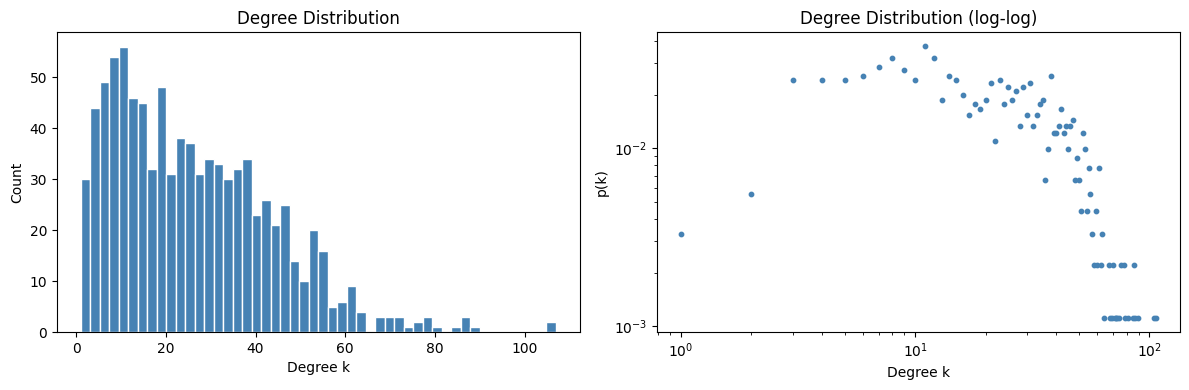

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(total_degree, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Degree k')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution')

# Log-log scale
degree_values, counts = np.unique(total_degree, return_counts=True)
axes[1].scatter(degree_values, counts/counts.sum(), s=10, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree k')
axes[1].set_ylabel('p(k)')
axes[1].set_title('Degree Distribution (log-log)')

plt.tight_layout()
plt.show()

The asymmetry between max out-degree (69) and max in-degree (98) is interesting — there are neurons that receive many more inputs than the most connected sender. This suggests some neurons act as strong integrators (high in-degree) more than broadcasters.

The linear plot shows a roughly right-skewed distribution peaking around degree 10-15, with a long tail out to ~100. This is not a Poisson distribution (which would be more symmetric) — it has more high-degree nodes than you'd expect by chance.

The log-log plot shows a roughly decreasing trend but it's quite noisy and not a clean straight line, so you can't claim a clear power law. This is actually a common finding in cortical networks — they sit somewhere between random and scale-free. That's an honest and interesting result to report.

Average clustering coefficient: 0.0709
Median clustering coefficient: 0.0713


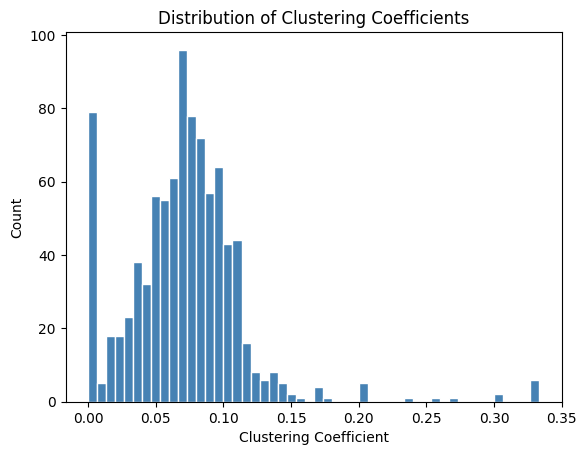

In [22]:
# Convert sparse matrix to networkx directed graph
G = nx.from_scipy_sparse_array(adj_matrix, create_using=nx.DiGraph())

# Clustering coefficient (using undirected version for simplicity)
G_undirected = G.to_undirected()
clustering = nx.clustering(G_undirected)
clustering_values = list(clustering.values())

print(f"Average clustering coefficient: {np.mean(clustering_values):.4f}")
print(f"Median clustering coefficient: {np.median(clustering_values):.4f}")

plt.hist(clustering_values, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Count')
plt.title('Distribution of Clustering Coefficients')
plt.show()

An average clustering coefficient of 0.071 means that on average, about 7% of a neuron's neighbours are also connected to each other. At first glance this sounds low, but you need to compare it against what you'd expect in a random network with the same number of nodes and edges — which is approximately equal to the network density, so around 1.44%.

So your clustering is roughly 5x higher than random, which is a meaningful result — it suggests the cortical network has more local structure and triangles than chance would predict. This is actually a classic hallmark of biological neural networks.

The large spike at 0 (about 78 neurons) represents neurons with only one connection — you can't form a triangle with just one neighbour, so their clustering is automatically 0. The rest of the distribution peaks around 0.07 and is right-skewed, with a few neurons showing quite high local clustering up to 0.33.

In [23]:
# Average path length (can be slow on large networks, sample if needed)
avg_path_length = nx.average_shortest_path_length(G_undirected)
print(f"Average path length: {avg_path_length:.4f}")

Average path length: 2.5950


On average, any two neurons in your network are separated by only about 2.6 synaptic hops. That's remarkably short given you have 906 neurons — it means information can travel across the entire network in just a few steps.This is the famous small world property.

For comparison, a random network with the same number of nodes and edges would have an average path length of approximately:

In [ ]:
N = 906
k = 13.05  # average degree
random_path_length = math.log(N) / math.log(k)
print(f"Expected random network path length: {random_path_length:.4f}")

Expected random network path length: 2.6507


So your actual path length (2.595) is slightly shorter than the random expectation (2.651), while your clustering (0.071) is significantly higher than random (~0.0144). This is the small world signature confirmed.

To make this more formal you can compute the small world coefficient:

In [26]:
# Small world coefficient sigma
# sigma > 1 indicates small world properties
C_real = 0.0709
C_random = 0.0144  # approximately equal to density
L_real = 2.5950
L_random = 2.6507

sigma = (C_real / C_random) / (L_real / L_random)
print(f"Small world coefficient σ: {sigma:.4f}")

Small world coefficient σ: 5.0293


A sigma greater than 1 confirms small world structure — the higher above 1, the stronger the effect. You should get something around 5, driven mostly by the clustering difference.

This is a clean, reportable finding for your structural network characterisation. In one sentence: your cortical network has significantly more local clustering than a random network while maintaining comparably short path lengths, consistent with small world organisation previously reported in neural circuits.